## Objetivo: a partir de los datos de ventas de libros proyectar las ventas del proximo mes

In [1]:
# Importo las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargo el dataset

df = pd.read_excel("Data/data.xlsx",  skiprows = 1,usecols = 'C:AU')

In [3]:
df

,TITLE,AUTHOR,LABEL,DIVISION,LAUCNCH DATE,SEGMENT,TYPE,PVP,Ener,Feb,...,Abr.2,May.2,Jun.2,Jul.2,Agos.2,Sept.2,Oct.2,Nov.2,Dic.2,Ener.3
0,Libro 1,Autor 1,GRJ-020,COMERCIAL,1999-01-01,AUTOAYUDA Y SUPERACIÓN,FONDO,259,17.0,9.0,...,18,19,73,194,107,121,101,106,241,120
1,Libro 2,Autor 2,AGL-021,COMERCIAL,2009-11-01,AUTOAYUDA,FONDO,239,13.0,18.0,...,5,0,11,12,13,16,14,8,30,11
2,Libro 3,Autor 3,ALF-022,LITERARIA,2010-09-01,BIBLIOTECA SARAMAGO,FONDO,329,133.0,122.0,...,31,9,31,88,50,71,87,61,111,33
3,Libro 4,Autor 4,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,161.0,115.0,...,43,43,76,142,106,91,67,67,153,56
4,Libro 5,Autor 5,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,68.0,86.0,...,34,73,71,99,82,77,64,69,125,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,Libro 653,Autor 653,ALFJ-025,INFANTIL Y JUVENIL,2018-12-01,FICCIÓN JUVENIL,FONDO,309,0.0,0.0,...,0,0,1,2,2,4,0,2,2,2
652,Libro 654,Autor 654,ALFI-031,INFANTIL Y JUVENIL,2018-12-01,MIDDLE GRADE,FONDO,199,0.0,0.0,...,0,1,2,2,1,5,1,4,2,3
653,Libro 655,Autor 655,LUM-030,LITERARIA,2018-12-01,LUMEN,FONDO,289,0.0,0.0,...,12,7,22,12,15,26,61,71,136,48
654,Libro 656,Autor 656,ROCI-028,INFANTIL Y JUVENIL,2018-12-01,JUVENIL,FONDO,249,0.0,0.0,...,6,1,5,10,5,5,5,7,30,11


In [4]:
#Creo un vector de secuencia de fechas mensuales

import datetime

#Vector de meses
meses = pd.date_range('1/1/2018', periods = 37, freq ='MS').strftime("%Y-%m-%d").tolist()

#Nombre del resto de las columnas
columnas = ['TITLE','AUTHOR','LABEL','DIVISION','LAUCNCH DATE','SEGMENT','TYPE','PVP']

#Concateno las listas
labels = np.concatenate([columnas,meses])

#Renombro el data frame
df.columns = labels

df.head()


,TITLE,AUTHOR,LABEL,DIVISION,LAUCNCH DATE,SEGMENT,TYPE,PVP,2018-01-01,2018-02-01,...,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01
0,Libro 1,Autor 1,GRJ-020,COMERCIAL,1999-01-01,AUTOAYUDA Y SUPERACIÓN,FONDO,259,17.0,9.0,...,18,19,73,194,107,121,101,106,241,120
1,Libro 2,Autor 2,AGL-021,COMERCIAL,2009-11-01,AUTOAYUDA,FONDO,239,13.0,18.0,...,5,0,11,12,13,16,14,8,30,11
2,Libro 3,Autor 3,ALF-022,LITERARIA,2010-09-01,BIBLIOTECA SARAMAGO,FONDO,329,133.0,122.0,...,31,9,31,88,50,71,87,61,111,33
3,Libro 4,Autor 4,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,161.0,115.0,...,43,43,76,142,106,91,67,67,153,56
4,Libro 5,Autor 5,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,68.0,86.0,...,34,73,71,99,82,77,64,69,125,71


In [5]:
#hago un melt con el data frame

df = df.melt(id_vars= columnas, var_name= "Fecha",value_name= "Cantidad")

df


,TITLE,AUTHOR,LABEL,DIVISION,LAUCNCH DATE,SEGMENT,TYPE,PVP,Fecha,Cantidad
0,Libro 1,Autor 1,GRJ-020,COMERCIAL,1999-01-01,AUTOAYUDA Y SUPERACIÓN,FONDO,259,2018-01-01,17.0
1,Libro 2,Autor 2,AGL-021,COMERCIAL,2009-11-01,AUTOAYUDA,FONDO,239,2018-01-01,13.0
2,Libro 3,Autor 3,ALF-022,LITERARIA,2010-09-01,BIBLIOTECA SARAMAGO,FONDO,329,2018-01-01,133.0
3,Libro 4,Autor 4,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,2018-01-01,161.0
4,Libro 5,Autor 5,DEB-023,BOLSILLO,2011-05-01,CONTEMPORÁNEA,FONDO,209,2018-01-01,68.0
...,...,...,...,...,...,...,...,...,...,...
24267,Libro 653,Autor 653,ALFJ-025,INFANTIL Y JUVENIL,2018-12-01,FICCIÓN JUVENIL,FONDO,309,2021-01-01,2.0
24268,Libro 654,Autor 654,ALFI-031,INFANTIL Y JUVENIL,2018-12-01,MIDDLE GRADE,FONDO,199,2021-01-01,3.0
24269,Libro 655,Autor 655,LUM-030,LITERARIA,2018-12-01,LUMEN,FONDO,289,2021-01-01,48.0
24270,Libro 656,Autor 656,ROCI-028,INFANTIL Y JUVENIL,2018-12-01,JUVENIL,FONDO,249,2021-01-01,11.0


In [6]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

df['Cantidad'] = df['Cantidad'].fillna(0)

df.isnull().sum()



TITLE           0
AUTHOR          0
LABEL           0
DIVISION        0
LAUCNCH DATE    0
SEGMENT         0
TYPE            0
PVP             0
Fecha           0
Cantidad        0
dtype: int64

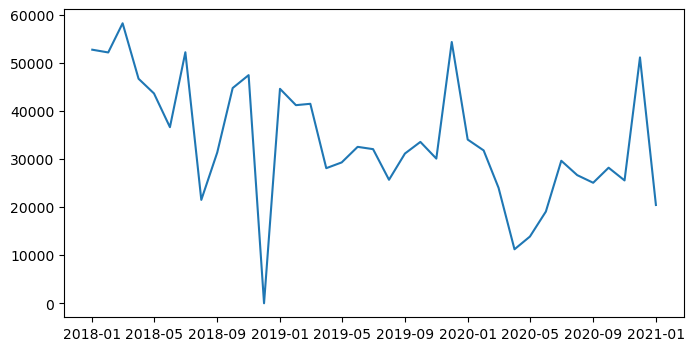

In [7]:
#Visalizamos la serie de tiempo en general


df_agrupado = df.groupby('Fecha', as_index=False).sum('Cantidad')


fig, ax = plt.subplots(figsize=(8,4))

plt.plot(df_agrupado["Fecha"], df_agrupado["Cantidad"])
plt.show()

In [8]:
#Agregamos la columa mes, quarter, year


df_agrupado['Mes'] = pd.DatetimeIndex(df_agrupado['Fecha']).month
df_agrupado['Anio'] = pd.DatetimeIndex(df_agrupado['Fecha']).year
df_agrupado['Trim'] = pd.DatetimeIndex(df_agrupado['Fecha']).quarter

df_agrupado= df_agrupado.sort_index()


<AxesSubplot:title={'center':'Cantidad'}, xlabel='Trim'>

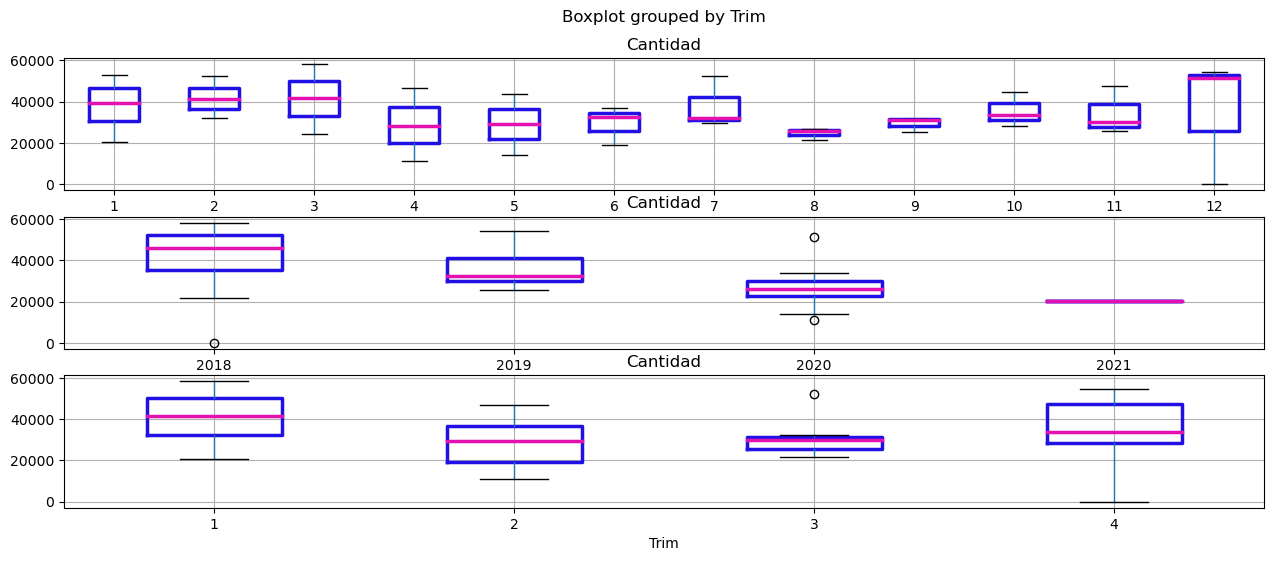

In [9]:
#Vemos estacionalidad con valores inferiores a enero 2021

fig1, ax = plt.subplots(3, figsize=(15, 6))

plt.suptitle('')
ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[2].set_xlabel("")

boxprops = dict(linestyle='-', linewidth=2.5, color='#2110e3')
medianprops = dict(linestyle='-', linewidth=2.5, color='#e310b2')

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Mes', ax=ax[0],
                 showfliers=False, showmeans=False,boxprops=boxprops,medianprops=medianprops)

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Anio', ax=ax[1],
                                                 boxprops=boxprops,medianprops=medianprops)

df_agrupado.query("Fecha < '2022-01-01'").boxplot(column=['Cantidad'], by= 'Trim', ax=ax[2],
                                                 boxprops=boxprops,medianprops=medianprops)


In [10]:
#Armo el dataset para el forecast

st_libros = df.groupby(["TITLE","Fecha"],as_index=False).sum("Cantidad")

#Imputo valor a diciembre 2018 con el promedio de 2019 y 2020

#Promedio libros diciembre 2019 y 2020

prom_libros = st_libros.query("Fecha == '2019-12-31' | Fecha == '2020-12-31'").groupby(["TITLE"]).mean('Cantidad').reset_index()

#Creo la variable fecha
prom_libros['Fecha'] = pd.to_datetime('2018-12-31')


#Agrego a st_libros sin 2018, el promedio de 2019 y 2020
st_libros = st_libros.query("Fecha != '2018-12-31'").append(prom_libros)




#Observo la tendencia



C:\Users\hernan.hernandez\AppData\Local\Temp\ipykernel_19960\3723754842.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  st_libros = st_libros.query("Fecha != '2018-12-31'").append(prom_libros)


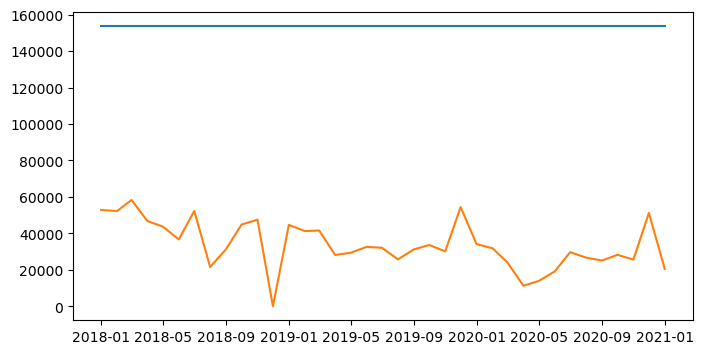

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

plt.plot(st_libros.groupby(['Fecha']).sum('Cantidad'))
plt.show()

In [12]:
#Creamos los modelos de forecast: una regresion lineal simple y un random forest

#Importamos las librerias

from sklearn.ensemble import RandomForestRegressor
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
import multiprocessing

In [13]:
st_libros=st_libros.drop('PVP', axis=1)

In [ ]:
#Armo un dataframe con libro 1 para crear el modelo antes de escalarlo al resto

libro_1 = st_libros.query("TITLE == 'Libro 1'")

#Convierto la variable fecha en numérica

libro_1['Time'] = np.arange(len(libro_1.index))

libro_1

#Dividimos el dataset en train y test

X_train, X_test, y_train, y_test = train_test_split(
                                        libro_1.drop(['TITLE','Fecha','Cantidad'],axis=1),
                                        libro_1['Cantidad'],
                                        random_state = 123)

In [15]:
#Creamos el modelo

reg = linear_model.LinearRegression()

reg.fit(X_train,y_train)

LinearRegression()

In [16]:
#Realizamos las primeras predicciones sin tuning

predicciones = reg.predict(X_test)
predicciones

array([ 49.8981688 ,  55.96628151,  71.13656328,  65.06845057,
        46.86411244, 128.78363403, 101.47712683, 125.74957767,
        68.10250693,  86.30684506])

In [17]:
rmse = mean_squared_error(y_test, predicciones, squared=False)
rmse

60.68915685106596

In [58]:
prueba = st_libros.query("TITLE == ['Libro 1','Libro 2','Libro 3']")
prueba['Time'] = np.arange(len(prueba.index))



C:\Users\hernan.hernandez\AppData\Local\Temp\ipykernel_19960\3184196392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prueba['Time'] = np.arange(len(prueba.index))


In [59]:
X_train = []
X_test = []
y_train = []
y_test = []


libros = prueba['TITLE'].unique()

for i in range(0,len(prueba['TITLE'].unique())):
    print(i)
    
    X_train,X_test,y_train,y_test = train_test_split(
    prueba[prueba['TITLE'] == libros[i]].drop(['TITLE','Fecha','Cantidad'],axis=1),
    prueba[prueba['Cantidad'] == libros[i]],
    random_state = 123)
    #Agrego los valores
    X_train.append(X_train)

0


ValueError: Found input variables with inconsistent numbers of samples: [37, 0]

[Tutorial piola](https://moez-62905.medium.com/multiple-time-series-forecasting-in-python-fab0a8a1afdb)

In [54]:
a_ver = []

libros = prueba['TITLE'].unique()

for i in range(1,len(prueba['TITLE'].unique())):
    prueba[prueba['TITLE'] == libros[i]].drop(['TITLE','Fecha','Cantidad'],axis=1)
    a_ver.append(prueba)
a_ver[0]

,TITLE,Fecha,Cantidad,Time
0,Libro 1,2018-01-01,17.0,0
1,Libro 1,2018-02-01,9.0,1
2,Libro 1,2018-03-01,7.0,2
3,Libro 1,2018-04-01,15.0,3
4,Libro 1,2018-05-01,20.0,4
...,...,...,...,...
8246,Libro 3,2020-09-01,71.0,106
8247,Libro 3,2020-10-01,87.0,107
8248,Libro 3,2020-11-01,61.0,108
8249,Libro 3,2020-12-01,111.0,109


In [86]:
prueba.query(f"TITLE == 'libros[1]'")['Cantidad']



Series([], Name: Cantidad, dtype: float64)